In [1]:
from pymob import Config

from lotka_volterra_UDE_case_study.mod import Func
import jax.random as jrandom
import jax.numpy as jnp
from pymob import Config
import matplotlib.pyplot as plt
from pymob.simulation import SimulationBase
from pymob.solvers.diffrax import UDESolver

# jax.config.update('jax_enable_x64', True)

c:\Users\Markus\anaconda3\envs\pymob3\Lib\site-packages\sympy2jax\sympy_module.py:290: UserWarning: `equinox.static_field` is deprecated in favour of `equinox.field(static=True)`
  has_extra_funcs: bool = eqx.static_field()


create a simulation from a config file, run it, and infer the optimal parameters

In [2]:
# Load configuration to a Config instance
config = Config("../scenarios/InfererTest/settings.cfg")

# Create a new simulation from the configuration
sim2 = SimulationBase(config)

sim2.config.case_study.data_path = "../data"

In [3]:
# Add data and initial conditions to the simulation
sim2.initialize(config)

# Add model, model parameters, and solver to the simulation
key = jrandom.PRNGKey(5678)
data_key, model_key, loader_key = jrandom.split(key, 3)
sim2.model = Func({"alpha":jnp.array(1.3), "delta":jnp.array(1.8)},key=model_key)
sim2.model_parameters["parameters"] = sim2.config.model_parameters.value_dict
sim2.model_parameters["y0"] = sim2.observations.sel(time = 0).drop_vars("time")
sim2.solver = UDESolver

C:\Users\Markus\pymob\pymob\simulation.py:1432: UserWarning: Using default initialize method, (load observations, define 'y0', define 'x_in'). This may be insufficient for more complex simulations.
  warnings.warn(


MinMaxScaler(variable=prey, min=0.30178511142730713, max=7.541078090667725)
MinMaxScaler(variable=predator, min=0.11841753125190735, max=5.719013214111328)


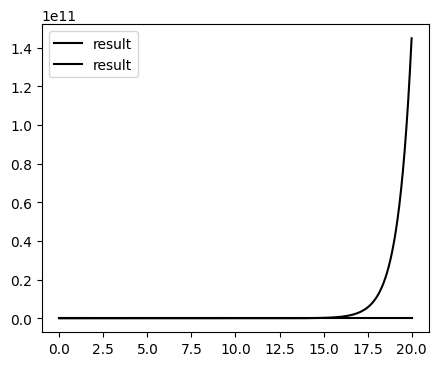

In [4]:
# Put everything in place for running the simulation
sim2.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator2 = sim2.dispatch()
evaluator2()
data_res = evaluator2.results

# Plot the results
fig, ax = plt.subplots(figsize=(5, 4))
# ax.plot(test_data.time, test_data.prey.sel(batch_id = 1), ls="-", color="tab:blue", alpha=.5, label ="observation data")
# ax.plot(test_data.time, test_data.predator.sel(batch_id = 1), ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_res.time, data_res.prey.sel(batch_id = 1), color="black", label ="result")
ax.plot(data_res.time, data_res.predator.sel(batch_id = 1), color="black", label ="result")
# ax.plot(test_data.time, test_data.prey, ls="-", color="tab:blue", alpha=.5, label ="observation data")
# ax.plot(test_data.time, test_data.predator, ls="-", color="tab:blue", alpha=.5, label ="observation data")
# ax.plot(data_res.time, data_res.prey, color="black", label ="result")
# ax.plot(data_res.time, data_res.predator, color="black", label ="result")
ax.legend()

In [5]:
sim2.set_inferer("optax")

sim2.inferer.run()

3 of 3 runs completed: 100%|█████████▉| 3299.9999999998167/3300.0 [06:20<00:00,  8.68it/s, 0 unsuccessful runs so far]    



run number	successful?	loss

run 1		yes		2.2590839862823486
run 2		yes		0.05836641043424606
run 3		yes		0.13672125339508057


array([<Axes: xlabel='time', ylabel='predator'>,
       <Axes: xlabel='time', ylabel='predator'>,
       <Axes: xlabel='time', ylabel='predator'>], dtype=object)

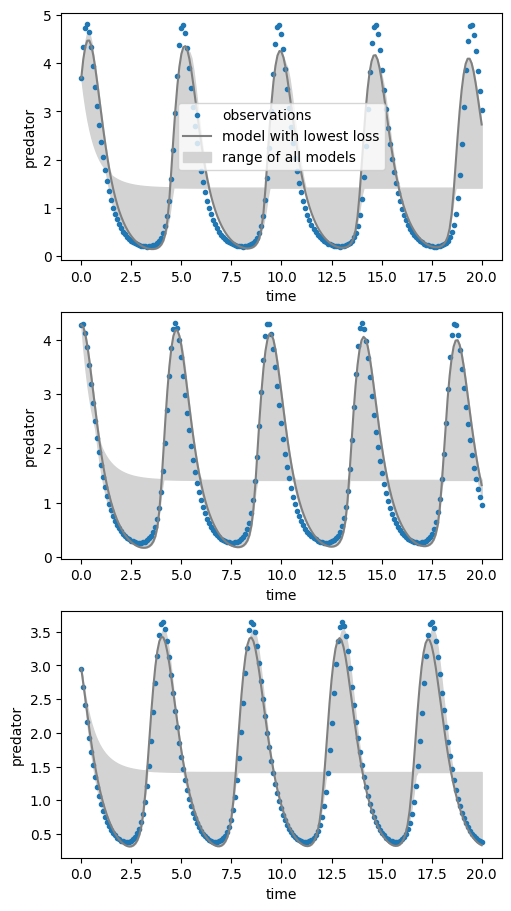

In [6]:
sim2.inferer.plot_posterior_predictions("predator", "time", n=3)